<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Testing out Indicators across various Stocks to Validate
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

# Import Packages

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime, timedelta
import os
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.formula.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import yfinance as yf
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement
import Charts

# Grab Data for one Ticker

In [2]:
tickers = Indicators.save_sp500_tickers()
ticker = tickers[0]
ticker = 'GRMN'
#ticker = 'WDC'
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
df = Indicators.get_ticker(ticker,500)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker
0,2022-04-18 09:30:00-04:00,110.589996,111.446404,110.370003,110.870003,64429,0.0,0.0,2022-04-18 09:30:00,GRMN
1,2022-04-18 10:30:00-04:00,110.879997,111.169998,110.239998,110.309998,60168,0.0,0.0,2022-04-18 10:30:00,GRMN
2,2022-04-18 11:30:00-04:00,110.415001,110.415001,109.889999,110.089996,72153,0.0,0.0,2022-04-18 11:30:00,GRMN
3,2022-04-18 12:30:00-04:00,110.070000,110.400002,110.046997,110.339996,36539,0.0,0.0,2022-04-18 12:30:00,GRMN
4,2022-04-18 13:30:00-04:00,110.360001,111.029999,110.360001,110.757202,45762,0.0,0.0,2022-04-18 13:30:00,GRMN
...,...,...,...,...,...,...,...,...,...,...
3479,2024-04-12 11:30:00-04:00,144.199997,144.199997,143.750000,143.910004,68826,0.0,0.0,2024-04-12 11:30:00,GRMN
3480,2024-04-12 12:30:00-04:00,143.910004,143.964996,143.050003,143.050003,68126,0.0,0.0,2024-04-12 12:30:00,GRMN
3481,2024-04-12 13:30:00-04:00,143.044006,143.535004,142.910004,143.335007,72890,0.0,0.0,2024-04-12 13:30:00,GRMN
3482,2024-04-12 14:30:00-04:00,143.320007,143.369995,142.865005,143.080002,91622,0.0,0.0,2024-04-12 14:30:00,GRMN


# Add SMA, Min/Max, Events

In [3]:
SMAs = [5,30,60,90]
smoothing = 7
window = 7

df = Indicators.get_sma(df,SMAs)
events_df = {}
minmax = Indicators.get_max_min(df, smoothing, window)
for event in events:
    events_df[event] = getattr(Indicators,event)(minmax)
#hs = Indicators.find_HS(minmax).reset_index(drop=True)
#invhs = Indicators.find_IHS(minmax).reset_index(drop=True)
#rw = Indicators.find_RW(minmax,.03).reset_index(drop=True)
#fw = Indicators.find_FW(minmax,.03).reset_index(drop=True)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,SMA5,SMA30,SMA60,SMA90
0,2022-04-18 09:30:00-04:00,110.589996,111.446404,110.370003,110.870003,64429,0.0,0.0,2022-04-18 09:30:00,GRMN,NaN,NaN,NaN,NaN
1,2022-04-18 10:30:00-04:00,110.879997,111.169998,110.239998,110.309998,60168,0.0,0.0,2022-04-18 10:30:00,GRMN,NaN,NaN,NaN,NaN
2,2022-04-18 11:30:00-04:00,110.415001,110.415001,109.889999,110.089996,72153,0.0,0.0,2022-04-18 11:30:00,GRMN,NaN,NaN,NaN,NaN
3,2022-04-18 12:30:00-04:00,110.070000,110.400002,110.046997,110.339996,36539,0.0,0.0,2022-04-18 12:30:00,GRMN,NaN,NaN,NaN,NaN
4,2022-04-18 13:30:00-04:00,110.360001,111.029999,110.360001,110.757202,45762,0.0,0.0,2022-04-18 13:30:00,GRMN,110.473439,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,2024-04-12 11:30:00-04:00,144.199997,144.199997,143.750000,143.910004,68826,0.0,0.0,2024-04-12 11:30:00,GRMN,144.973004,147.009378,146.694746,147.051597
3480,2024-04-12 12:30:00-04:00,143.910004,143.964996,143.050003,143.050003,68126,0.0,0.0,2024-04-12 12:30:00,GRMN,144.245004,146.828501,146.623247,146.998319
3481,2024-04-12 13:30:00-04:00,143.044006,143.535004,142.910004,143.335007,72890,0.0,0.0,2024-04-12 13:30:00,GRMN,143.698004,146.631668,146.573897,146.957264
3482,2024-04-12 14:30:00-04:00,143.320007,143.369995,142.865005,143.080002,91622,0.0,0.0,2024-04-12 14:30:00,GRMN,143.507004,146.423835,146.531396,146.917264


# Plot All Events

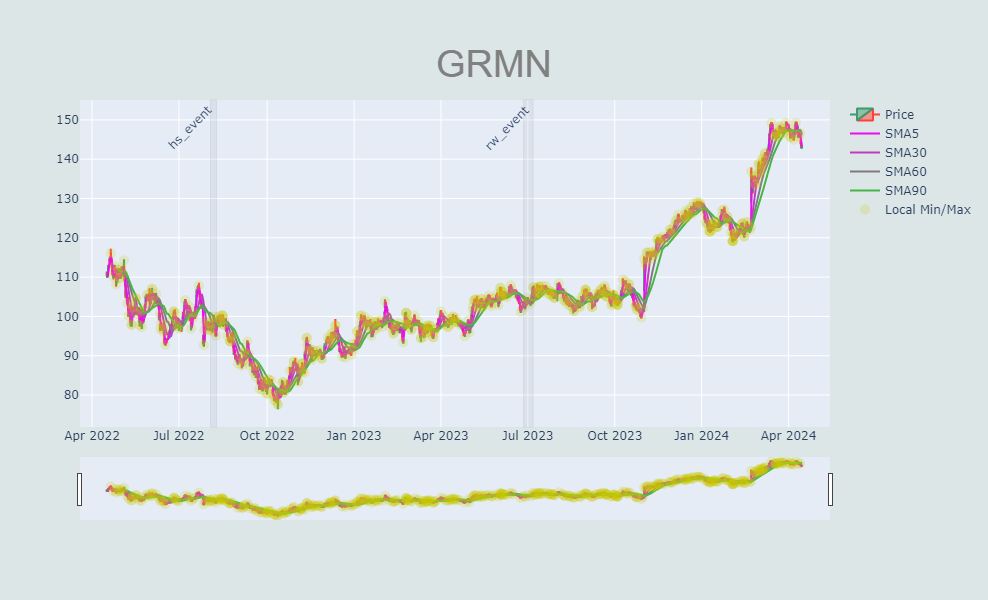

In [4]:
Charts.chart_all(df,events,events_df,SMAs,minmax)

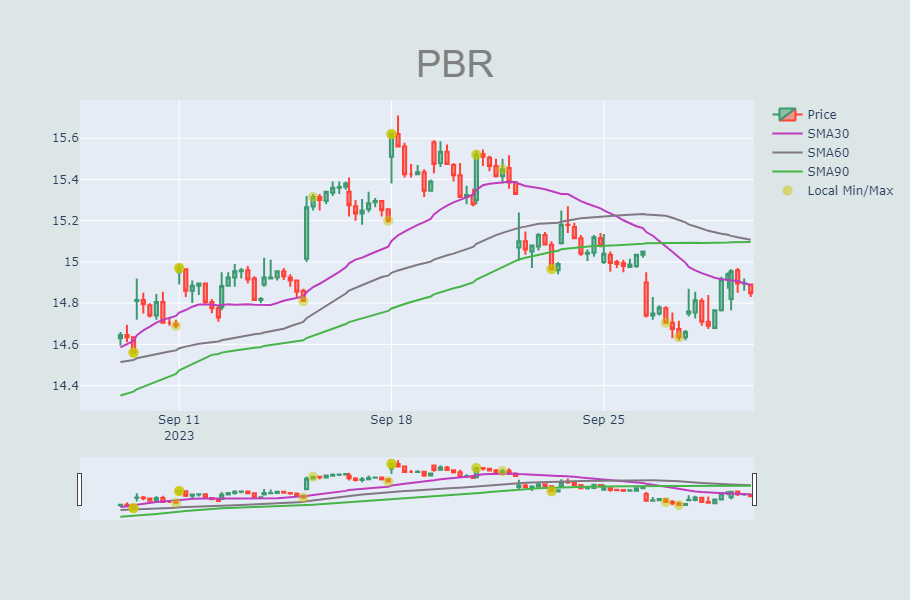

In [46]:
df2 = Indicators.main(ticker,500,SMAs,smoothing,window)
eventType = 'rw_event'
ID = list(df2[df2.date==df2[df2[eventType]==1].date.min()].index)[0]
chartdf = df2.iloc[ID-10:ID+95].copy()
minmax2 = minmax[(minmax.date>=chartdf.date.min())&(minmax.date<=chartdf.date.max())].copy()
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=chartdf['date'],
                open=chartdf['open'],
                high=chartdf['high'],
                low=chartdf['low'],
                close=chartdf['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=chartdf['date'],
                y=chartdf['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax2['date'],
                y=minmax2['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.5)
                        ))
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

# Add Variables for Measurement Main Function

In [4]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
bound = 0.03
SMAs = [30,60,90]

### Run Measurement Main

In [5]:
df3, final4 = Measurement.main(events, SMAs, smoothing, window, M, K, bound)

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


### Check df3 for one Event

In [15]:
event = 'fw_event'
df3.groupby(['ticker',event + '_start_time',event + '_end_time']).agg({'volume':'size',event:'mean'}).reset_index().head(5)

,ticker,fw_event_start_time,fw_event_end_time,volume,fw_event
0,A,2022-04-18 09:30:00,2023-09-13 10:30:00,2467,0.0
1,A,2023-09-13 11:30:00,2023-09-21 15:30:00,47,1.0
2,A,2023-09-22 09:30:00,2024-04-12 15:30:00,977,0.0
3,AAL,2022-04-18 09:30:00,2022-05-03 13:30:00,82,0.0
4,AAL,2022-05-03 14:30:00,2022-05-12 13:30:00,49,1.0


### Run Chart for One Event & Ticker

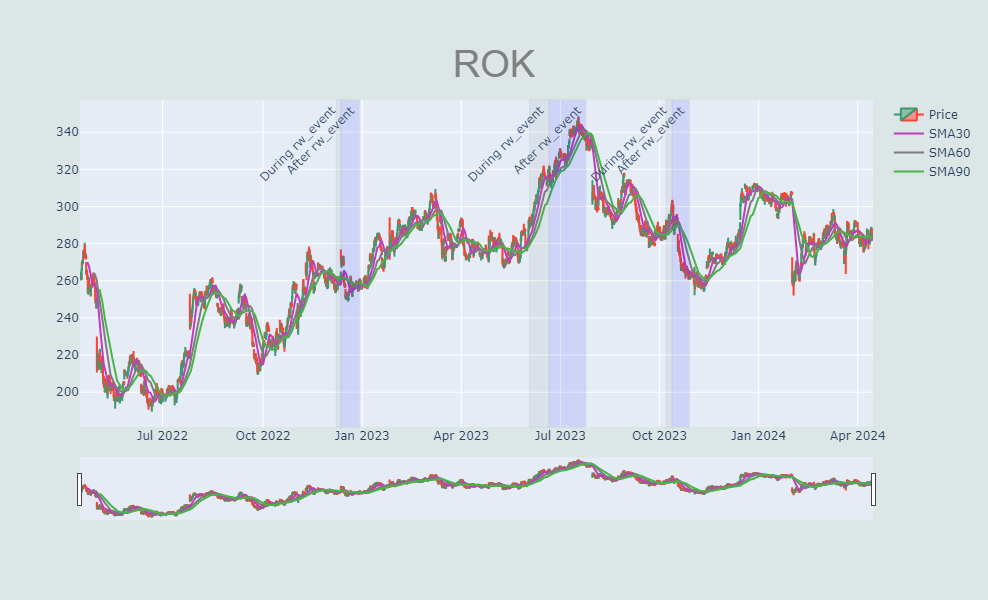

In [20]:
event = 'rw_event'
ticker = 'ROK'
    
Charts.chart_event(df3,event,ticker,SMAs)

### Final Result for Prefect/Slack

In [13]:
final4.sort_values(['event_end_time'],ascending=0).head(15)

,index,ticker,event,event_observations,event_start_time,event_end_time,after_event_observations,after_event_mean,after_event_start_time,after_event_end_time,count,mean,min,median,max,Indicator,event_count,event_success,stock_success
1443,436,TSLA,ihs_event,50.0,2024-04-02 09:30:00,2024-04-11 09:30:00,1.0,0.005495,2024-04-11 09:30:00,2024-04-12 15:30:00,3126.0,0.088862,-0.064117,0.075435,0.385623,0,1.0,0.757282,0.0
1378,322,MTD,ihs_event,46.0,2024-04-02 12:30:00,2024-04-10 15:30:00,1.0,0.019947,2024-04-10 15:30:00,2024-04-12 15:30:00,3216.0,0.050875,-0.021285,0.043394,0.193057,0,1.0,0.757282,1.0
592,123,CHTR,fw_event,84.0,2024-03-26 15:30:00,2024-04-10 13:30:00,1.0,0.007562,2024-04-10 13:30:00,2024-04-12 15:30:00,2851.0,0.051702,-0.128364,0.044155,0.190447,0,2.0,0.828358,0.5
1376,320,MTCH,ihs_event,38.0,2024-04-02 15:30:00,2024-04-10 10:30:00,1.0,0.043299,2024-04-10 10:30:00,2024-04-12 15:30:00,2488.0,0.078684,-0.079542,0.069148,0.255982,0,1.0,0.757282,1.0
1193,32,APTV,ihs_event,36.0,2024-04-03 09:30:00,2024-04-10 09:30:00,1.0,0.030058,2024-04-10 09:30:00,2024-04-12 15:30:00,2632.0,0.053472,-0.036971,0.038911,0.243948,0,3.0,0.757282,1.0
183,293,FCX,rw_event,77.0,2024-03-25 09:30:00,2024-04-09 15:30:00,1.0,-0.001213,2024-04-09 15:30:00,2024-04-12 15:30:00,2610.0,-0.074500,-0.495300,-0.052633,0.058955,0,1.0,0.751724,0.0
1225,80,CEG,ihs_event,43.0,2024-04-01 09:30:00,2024-04-09 09:30:00,1.0,0.066264,2024-04-09 09:30:00,2024-04-12 15:30:00,2949.0,0.063859,-0.019634,0.046914,0.329010,1,2.0,0.757282,0.0
470,735,TRGP,rw_event,65.0,2024-03-25 13:30:00,2024-04-08 14:30:00,1.0,-0.000480,2024-04-08 14:30:00,2024-04-12 15:30:00,2752.0,-0.053180,-0.388646,-0.035514,0.028137,0,2.0,0.751724,0.5
1452,446,UBER,ihs_event,33.0,2024-04-02 09:30:00,2024-04-08 13:30:00,1.0,0.018199,2024-04-08 13:30:00,2024-04-12 15:30:00,2703.0,0.090583,-0.031716,0.072670,0.346064,0,2.0,0.757282,0.0
373,595,ODFL,rw_event,93.0,2024-03-25 09:30:00,2024-04-08 12:30:00,1.0,-0.019581,2024-04-08 12:30:00,2024-04-12 15:30:00,2859.0,-0.055278,-0.257305,-0.045352,0.035859,0,1.0,0.751724,1.0


### Check Results by Event

In [11]:
final4[(final4['event_observations']> 10)&
      (pd.to_datetime(final4['after_event_end_time'])<(datetime.today()-timedelta(days=1)))]. \
        groupby(['event']).Indicator.describe()

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
fw_event,418.0,0.700957,0.458387,0.0,0.0,1.0,1.0,1.0
hs_event,219.0,0.392694,0.489468,0.0,0.0,0.0,1.0,1.0
ihs_event,296.0,0.682432,0.466319,0.0,0.0,1.0,1.0,1.0
rw_event,503.0,0.606362,0.489043,0.0,0.0,1.0,1.0,1.0


In [25]:
from tabulate import tabulate
df_print = final4.sort_values(['event_end_time'],ascending=0).head(15)
df_print.drop(['index','after_event_observations','after_event_mean','count','mean','min','median','max','Indicator'],axis=1,inplace=True)
    
print(tabulate(df_print, headers='keys', tablefmt="grid"))

+------+----------+-----------+----------------------+---------------------+---------------------+--------------------------+------------------------+---------------+-----------------+-----------------+
|      | ticker   | event     |   event_observations | event_start_time    | event_end_time      | after_event_start_time   | after_event_end_time   |   event_count |   event_success |   stock_success |
+======+==========+===========+======================+=====================+=====================+==========================+========================+===============+=================+=================+
| 1443 | TSLA     | ihs_event |                   50 | 2024-04-02 09:30:00 | 2024-04-11 09:30:00 | 2024-04-11 09:30:00      | 2024-04-12 15:30:00    |             1 |        0.757282 |             0   |
+------+----------+-----------+----------------------+---------------------+---------------------+--------------------------+------------------------+---------------+-----------------+----